In [1]:
import os
import pandas as pd
import numpy as np
import boto3
from tqdm import tqdm
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
# Suppress PerformanceWarning
warnings.filterwarnings('ignore')
import sklearn.metrics as skm
from sklearn.linear_model import LogisticRegression

try:
    import catboost as cb
except:
    ! pip install catboost

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.0' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


### Functions

In [2]:
# download from s3
def download_from_s3(str_local_path, str_bucket_path, str_project):
    # download file
    boto3.client('s3').download_file(str_project, str_bucket_path, str_local_path)

In [3]:
# upload to s3
def upload_to_s3(str_local_path, str_bucket_key, str_bucket_name):
    # upload file
    boto3.client('s3').upload_file(str_project, str_bucket_path, str_local_path)

In [4]:
# show added factors
def show_best_added_factor(df_tmp, list_flt_factor, str_key):
    # find factor
    dict_list_distributions = {}
    list_dict_row = []
    for flt_factor in tqdm(list_flt_factor):
        # add factor
        df_tmp['tmp'] = df_tmp['predictions'] + flt_factor
        
        # save distribution of residuals
        dict_list_distributions[flt_factor] = list(df_tmp['tmp'] - df_tmp['actual'])
        
        # get score
        flt_score = skm.log_loss(
            y_true=df_tmp['actual'],
            y_pred=df_tmp['tmp'],
        )
        # dict row
        dict_row = {
            'factor': flt_factor,
            'score': flt_score,
        }
        list_dict_row.append(dict_row)
    # df
    df_tmp = pd.DataFrame(list_dict_row)
    
    # get best factor
    df_tmp.sort_values(by='score', ascending=True, inplace=True)
    flt_factor = df_tmp['factor'].iloc[0]
    flt_best_score = df_tmp['score'].iloc[0]
    list_distribution_best = dict_list_distributions[flt_factor]
    
    # get 0
    flt_score_0 = df_tmp[df_tmp['factor'] == 0]['score'].iloc[0]
    list_distribution_0 = dict_list_distributions[0]
    
    # sort for plot
    df_tmp.sort_values(by='factor', ascending=True, inplace=True)
    
    # title
    str_title = f"""
    Log-loss by Factor Added or Subtracted for {str_key} (N = {df_tmp.shape[0]})
    Best Factor = {flt_factor:0.04f}; Score = {flt_best_score:0.4f}
    Score at 0 = {flt_score_0:0.4f}
    """
    # plot
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(str_title)
    ax.set_xlabel('Factor Added or Subtracted')
    ax.set_ylabel('Log-loss')
    ax.plot(df_tmp['factor'], df_tmp['score'])
    ax.axvline(x=flt_factor, color='r', linestyle='--')
    # show
    plt.show()
    
    # plot residuals
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title('Distributions of Residuals')
    ax.set_xlabel('Predicted - Actual')
    # best
    sns.kdeplot(list_distribution_best, ax=ax, label='Best')
    # 0
    sns.kdeplot(list_distribution_0, ax=ax, label='No Factor')
    # legend
    plt.legend()
    # show
    plt.show()
    
    # return
    return df_tmp

In [5]:
# show added factors
def show_best_multiplicative_factor(df_tmp, list_flt_factor, str_key):
    # find factor
    dict_list_distributions = {}
    list_dict_row = []
    for flt_factor in tqdm(list_flt_factor):
        # add factor
        df_tmp['tmp'] = df_tmp['predictions'] * flt_factor
        
        # save distribution of residuals
        dict_list_distributions[flt_factor] = list(df_tmp['tmp'] - df_tmp['actual'])
        
        # get score
        flt_score = skm.log_loss(
            y_true=df_tmp['actual'],
            y_pred=df_tmp['tmp'],
        )
        # dict row
        dict_row = {
            'factor': flt_factor,
            'score': flt_score,
        }
        list_dict_row.append(dict_row)
    # df
    df_tmp = pd.DataFrame(list_dict_row)
    
    # get best factor
    df_tmp.sort_values(by='score', ascending=True, inplace=True)
    flt_factor = df_tmp['factor'].iloc[0]
    flt_best_score = df_tmp['score'].iloc[0]
    list_distribution_best = dict_list_distributions[flt_factor]
    
    # get 1
    flt_score_1 = df_tmp[df_tmp['factor'] == 1]['score'].iloc[0]
    list_distribution_1 = dict_list_distributions[1]
    
    # get 1.52
    flt_score_pepo = df_tmp[df_tmp['factor'] == 1.52]['score'].iloc[0]
    list_distribution_pepo = dict_list_distributions[1.52]
    
    # sort for plot
    df_tmp.sort_values(by='factor', ascending=True, inplace=True)
    
    # title
    str_title = f"""
    Log-loss by Factor Multiplied for {str_key} (N = {df_tmp.shape[0]})
    Best Factor = {flt_factor:0.04f}; Score = {flt_best_score:0.4f}
    Score at 1 = {flt_score_1:0.4f}; Score at 1.52 = {flt_score_pepo:0.4f}
    """
    # plot
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(str_title)
    ax.set_xlabel('Factor Multiplied')
    ax.set_ylabel('Log-loss')
    ax.plot(df_tmp['factor'], df_tmp['score'])
    ax.axvline(x=flt_factor, color='r', linestyle='--')
    # show
    plt.show()
    
    # plot residuals
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title('Distributions of Residuals')
    ax.set_xlabel('Predicted - Actual')
    # best
    sns.kdeplot(list_distribution_best, ax=ax, label='Best')
    # 1
    sns.kdeplot(list_distribution_1, ax=ax, label='No Factor')
    # pepo
    sns.kdeplot(list_distribution_pepo, ax=ax, label='1.52')
    # legend
    plt.legend()
    # show
    plt.show()
    
    # return
    return df_tmp

In [6]:
# transformation
def transformation_tuner(df, str_predictor, str_target, str_key):
    # list trans
    list_str_trans = [
        'None',
        'Log',
        'Log10',
        'Square',
        'Square_Root',
        'Cube',
        'Cube_Root',
        'Reciprocal',
    ]
    # empty list
    dict_list_distributions = {}
    list_dict_row = []
    for str_trans in tqdm(list_str_trans):
        # copy df
        df_tmp = df.copy()
        # logic
        if str_trans == 'None':
            # apply transformation
            df_tmp[str_predictor] = df_tmp[str_predictor]
        elif str_trans == 'Log':
            # apply transformation
            df_tmp[str_predictor] = np.log(df_tmp[str_predictor])
        elif str_trans == 'Log10':
            # apply transformation
            df_tmp[str_predictor] = np.log10(df_tmp[str_predictor])
        elif str_trans == 'Square':
            # apply transformation
            df_tmp[str_predictor] = df_tmp[str_predictor] ** 2
        elif str_trans == 'Square_Root':
            # apply transformation
            df_tmp[str_predictor] = np.sqrt(df_tmp[str_predictor])
        elif str_trans == 'Cube':
            # apply transformation
            df_tmp[str_predictor] = df_tmp[str_predictor] ** 3
        elif str_trans == 'Cube_Root':
            # apply transformation
            df_tmp[str_predictor] = np.cbrt(df_tmp[str_predictor])
        elif str_trans == 'Reciprocal':
            # apply transformation
            df_tmp[str_predictor] = 1 / df_tmp[str_predictor]
        else:
            break
                
        # create X and y
        list_cols = [
            str_predictor,
        ]
        X = df_tmp[list_cols]
        y = df_tmp[str_target]
        # fit model
        cls_model = LogisticRegression()
        cls_model.fit(X, y)
        # get intercept
        flt_intercept = cls_model.intercept_[0]
        flt_coeff = cls_model.coef_[0][0]
        # get predictions
        df_tmp['yhat'] = cls_model.predict_proba(X)[:,1]
        # get residuals
        dict_list_distributions[str_trans] = list(df_tmp['yhat'] - df_tmp[str_target])
        
        # get rmse
        flt_score = skm.log_loss(
            y_true=df_tmp[str_target],
            y_pred=df_tmp['yhat'],
        )
        # make row
        dict_row = {
            'transformation': str_trans,
            'intercept': flt_intercept,
            'coefficient': flt_coeff,
            'score': flt_score,
        }
        list_dict_row.append(dict_row)
    # make df
    df_tmp = pd.DataFrame(list_dict_row)
    # sort
    df_tmp.sort_values(by='score', ascending=True, inplace=True)
    # get formula
    df_tmp['formula'] = df_tmp.apply(
        lambda x: f'{x["intercept"]:0.2f} + ({x["coefficient"]:0.2f} * {x["transformation"]}(x))',
        axis=1,
    )
    
    # get best
    str_factor = df_tmp['transformation'].iloc[0]
    flt_best_score = df_tmp['score'].iloc[0]
    
    # title
    str_title = f"""
    Log-loss by Logistic Regression Model Transformation for {str_key}
    Best Transformation = {str_factor}; Score = {flt_best_score:0.4f}
    """
    
    # plot
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(str_title)
    ax.set_xlabel('Transformation')
    ax.set_ylabel('Log-loss')
    ax.plot(df_tmp['transformation'], df_tmp['score'])
    plt.show()
    
    # plot residuals
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title('Distributions of Residuals by Transformation Type')
    ax.set_xlabel('Predicted - Actual')
    for key, val in dict_list_distributions.items():
        sns.kdeplot(val, ax=ax, label=key)
    plt.legend()
    plt.show()
    
    # reconfigure df_tmp
    dict_rename = {
        'formula': 'factor',
    }
    df_tmp.rename(columns=dict_rename, inplace=True)
    
    # subset
    list_cols = [
        'factor',
        'score',
    ]
    df_tmp = df_tmp[list_cols].copy()
    
    # return
    return df_tmp

### Constants

In [7]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')
str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')
str_dirname_output = './output'
str_variant = 'noPTImodel7'

# indicators
dict_model_column = {
    'DQ15_1': 'Early_Pay_Delinquency_15_30_Flag',
    'DQ15_2': 'Early_Pay_Delinquency_15_60_Flag',
    'DQ30_2': 'Early_Pay_Delinquency_30_60_Flag',
    'DQ60_3': 'Early_Pay_Delinquency_60_90_Flag',
}

# months
list_str_year_month = [
    '2021-10',
    '2021-11',
    '2021-12',
    '2022-01',
    '2022-02',
    '2022-03',
    '2022-04',
    '2022-05',
    '2022-06',
    '2022-07',
    '2022-08',
    '2022-09',
    '2022-10',
    '2022-11',
    '2022-12',
    '2023-01',
    '2023-02',
    '2023-03',
    '2023-04',
    '2023-05',
    '2023-06',
    '2023-07',
    '2023-08',
    '2023-09',
    '2023-10',
]
# note: production targets were pulled in 2024-02
# maximum days total of the targets is 90
# thus, to ensure all accounts have been 90 days (3 months) mature, I have subsetted to the latest date being 2023-11
# we can edit this as needed


# factors
int_n_factors = 1000

Project: 20231010-gen-xii
Task: 09_early_indicators


### Output directory

In [8]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

### Variant directory

In [9]:
try:
    os.mkdir(f'{str_dirname_output}/{str_variant}')
except:
    pass

### Get production predictions and actuals

In [10]:
# load data from retro scoring
str_filename = 'df.gzip'
str_uri = f's3://{str_project}/08_retro_scoring/06_create_df/{str_filename}'
df = pd.read_parquet(str_uri)

# convert to datetime
df['applicationdate__app'] = pd.to_datetime(df['applicationdate__app'])

# drop because they break preprocessing
list_cols = [
    'applicationdayofweek__app',
]
df.drop(list_cols, axis=1, inplace=True)

# get features 100% NaN and drop
ser_isnull = df.isnull().mean()
list_all_nan = list(ser_isnull[ser_isnull==1.0].index)
# logic
if str_variant == 'model3':
    list_all_nan = [col for col in list_all_nan if col != 'cvlst_s1__tu']
else:
    pass
df.drop(list_all_nan, axis=1, inplace=True)

# get month of application
df['year_month'] = df['applicationdate__app'].dt.strftime('%Y-%m')
# subset
df = df[df['year_month'].isin(list_str_year_month)].copy()

# show
df

,uniqueid__app_x,strcity__app,strname__app,strzipcode__app,bitapproved__app,bitsystemdecline__app,bitfunded__app,applicationmonth__app,applicationquarter__app,bigdealerid__app,...,fltapproveddowntotal__app,payment__app,dti__app,pti__app,bitservicecontract__app,fltadvance__app,strvehicletype__app,bitgap__app,dealerstampcreation__app,year_month
0,5838462__7328771__20211124,Burlington,Kentucky,41005,True,nan,True,11,4,2836.0,...,500.0,484.52,0.348085,0.124236,0,0.955681,auto,0,2013-05-08 08:47:59.997,2021-11
1,5874043__7369806__20211220,Dallas,Texas,75219,True,nan,True,12,4,1469.0,...,150.0,599.41,0.413636,0.137929,0,1.118242,suv,1,2010-07-07 16:51:47.837,2021-12
2,5827507__7315370__20211113,SAINT LOUIS,Missouri,63112,True,nan,True,11,4,5473.0,...,1000.0,438.12,0.320558,0.110788,0,1.092707,auto,1,2018-05-07 13:27:18.220,2021-11
3,5855839__7349888__20211211,COLLINSVILLE,Illinois,62234,True,nan,True,12,4,5235.0,...,2000.0,386.01,0.364331,0.122209,0,1.097128,auto,1,2017-09-18 16:02:07.110,2021-12
4,5874497__7370346__20211220,CHICAGO,Illinois,60652,True,nan,True,12,4,4535.0,...,1500.0,680.00,0.160800,0.068000,0,0.957552,suv,0,2016-03-15 15:36:18.820,2021-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59930,0__0__20231021,Smithfield,Utah,84335,False,0.0,False,10,4,NaN,...,1500.0,486.46,0.349207,0.149207,0,1.170020,auto,1,2018-04-24 12:07:58.037,2023-10
59932,0__0__20231007,DETROIT,Michigan,48203,False,0.0,False,10,4,NaN,...,0.0,634.69,0.346468,0.146467,0,1.149793,suv,1,2019-08-02 11:24:11.380,2023-10
59937,0__0__20231025,Belleville,Illinois,62226,False,0.0,False,10,4,NaN,...,0.0,471.34,0.472551,0.147551,0,1.107930,suv,0,2010-09-20 11:19:55.440,2023-10
59944,0__0__20231016,Charlestown,Indiana,47111,False,0.0,False,10,4,NaN,...,0.0,557.64,0.396662,0.044611,1,1.153356,auto,1,2022-08-31 11:41:53.960,2023-10


In [11]:
# get actual targets
str_filename = 'df_early_targets.csv'
str_uri = f's3://{str_project}/09_early_indicators/05_get_target_from_db/{str_filename}'
df_tmp = pd.read_csv(str_uri)

# join
df = pd.merge(
    left=df,
    right=df_tmp,
    on='bigAccountId',
    how='inner',
)
# show
df

,uniqueid__app_x,strcity__app,strname__app,strzipcode__app,bitapproved__app,bitsystemdecline__app,bitfunded__app,applicationmonth__app,applicationquarter__app,bigdealerid__app,...,Early_Pay_Delinquency_90_450_Flag,Early_Pay_Delinquency_90_480_Flag,Early_Pay_Delinquency_90_510_Flag,Early_Pay_Delinquency_90_540_Flag,Early_Pay_Delinquency_90_570_Flag,Early_Pay_Delinquency_90_600_Flag,Early_Pay_Delinquency_90_630_Flag,Early_Pay_Delinquency_90_660_Flag,Early_Pay_Delinquency_90_690_Flag,Early_Pay_Delinquency_90_720_Flag
0,5838462__7328771__20211124,Burlington,Kentucky,41005,True,nan,True,11,4,2836.0,...,1,1,1,1,1,1,1,1,1,1
1,5874043__7369806__20211220,Dallas,Texas,75219,True,nan,True,12,4,1469.0,...,0,1,1,1,1,1,1,1,1,1
2,5827507__7315370__20211113,SAINT LOUIS,Missouri,63112,True,nan,True,11,4,5473.0,...,1,1,1,1,1,1,1,1,1,1
3,5855839__7349888__20211211,COLLINSVILLE,Illinois,62234,True,nan,True,12,4,5235.0,...,0,0,0,1,1,1,1,1,1,1
4,5874497__7370346__20211220,CHICAGO,Illinois,60652,True,nan,True,12,4,4535.0,...,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57704,0__0__20231021,Smithfield,Utah,84335,False,0.0,False,10,4,NaN,...,0,0,0,0,0,0,0,0,0,0
57705,0__0__20231007,DETROIT,Michigan,48203,False,0.0,False,10,4,NaN,...,0,0,0,0,0,0,0,0,0,0
57706,0__0__20231025,Belleville,Illinois,62226,False,0.0,False,10,4,NaN,...,0,0,0,0,0,0,0,0,0,0
57707,0__0__20231016,Charlestown,Indiana,47111,False,0.0,False,10,4,NaN,...,0,0,0,0,0,0,0,0,0,0


### Preprocess so we can get production predictions

In [12]:
%%time

list_str_filename = [
    'preprocessing.py',
    'cls_model_preprocessing.pkl',
]
for str_filename in tqdm(list_str_filename):
    # download
    str_bucket_path = f'01_ad/02_model/{str_variant}/00_preprocessing/01_create_preprocessor/{str_filename}'
    str_local_path = f'./{str_filename}'
    download_from_s3(
        str_local_path=str_local_path, 
        str_bucket_path=str_bucket_path, 
        str_project=str_project,
    )
# import
cls_model_preprocessing = pickle.load(open(str_local_path, 'rb'))
# rm
os.remove(str_local_path)

# preprocess
df = cls_model_preprocessing.transform(df)

# rm
os.remove('./preprocessing.py')

# show
df

100%|██████████| 2/2 [00:00<00:00,  7.49it/s]


NaN Replacer: 0.41132 sec.


100%|██████████| 3/3 [00:00<00:00, 119.42it/s]

Unable to convert vehiclemodel__app to string, not found in data
Set strings: 0.027054 sec.


Boolean Replacer: 1.2438 sec.


...


100%|██████████| 1992/1992 [00:01<00:00, 1380.05it/s]


Replace inf and -inf with NaN: 1.8076 sec.
Imputer: 0.86776 sec.
Map term: 0.029428 sec.
Map PTI: 0.030313 sec.


100%|██████████| 9/9 [00:00<00:00, 1435.70it/s]

Round values: 0.0095881 sec.
Preprocessing Model: 9.5579 sec.
CPU times: user 8.11 s, sys: 1.62 s, total: 9.73 s
Wall time: 9.83 s


,uniqueid__app_x,strcity__app,strname__app,strzipcode__app,bitapproved__app,bitsystemdecline__app,bitfunded__app,applicationmonth__app,applicationquarter__app,bigdealerid__app,...,Early_Pay_Delinquency_90_690_Flag,Early_Pay_Delinquency_90_720_Flag,year,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-payment_to_income,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age
0,5838462__7328771__20211124,burlington,kentucky,41005,1.0,nan,1.0,11.0,4.0,2836.0,...,1,1,2021,1.080027,11,4,0.12,1.023810,3.0,8.550685
1,5874043__7369806__20211220,dallas,texas,75219,1.0,nan,1.0,12.0,4.0,1469.0,...,1,1,2021,1.080027,12,4,0.12,1.219512,3.0,11.460274
2,5827507__7315370__20211113,saintlouis,missouri,63112,1.0,nan,1.0,11.0,4.0,5473.0,...,1,1,2021,1.080027,11,4,0.09,1.166667,7.0,3.520548
3,5855839__7349888__20211211,collinsville,illinois,62234,1.0,nan,1.0,12.0,4.0,5235.0,...,1,1,2021,1.080027,12,4,0.09,1.269231,4.0,4.230137
4,5874497__7370346__20211220,chicago,illinois,60652,1.0,nan,1.0,12.0,4.0,4535.0,...,1,1,2021,1.080027,12,4,0.06,1.084746,3.0,5.767123
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57704,0__0__20231021,smithfield,utah,84335,0.0,0.0,0.0,10.0,4.0,0.0,...,0,0,2023,0.970000,10,4,0.12,1.370370,9.0,5.493151
57705,0__0__20231007,detroit,michigan,48203,0.0,0.0,0.0,10.0,4.0,0.0,...,0,0,2023,0.970000,10,4,0.15,1.285714,2.0,4.180822
57706,0__0__20231025,belleville,illinois,62226,0.0,0.0,0.0,10.0,4.0,0.0,...,0,0,2023,0.970000,10,4,0.09,1.218750,9.0,13.101370
57707,0__0__20231016,charlestown,indiana,47111,0.0,0.0,0.0,10.0,4.0,0.0,...,0,0,2023,0.970000,10,4,0.03,1.500000,3.0,1.123288


In [13]:
# get predictions
for key, val in tqdm(dict_model_column.items()):
    # get model
    str_filename = 'dict_model_inference.pkl'
    str_bucket_path = f'09_early_indicators/{str_variant}/best_models/models/{key}/{str_filename}'
    str_local_path = f'./{str_filename}'
    download_from_s3(
        str_local_path=str_local_path, 
        str_bucket_path=str_bucket_path, 
        str_project=str_project,
    )
    # import
    cls_model_inference = pickle.load(open(str_local_path, 'rb'))['model_inference']
    # rm
    os.remove(str_local_path)
    # predict proba
    list_cols_model = list(cls_model_inference.feature_names_)
    str_col_tmp = f'yhat_proba_{key}'
    df[str_col_tmp] = cls_model_inference.predict_proba(df[list_cols_model])[:,1]

# subset
list_cols = [col for col in df.columns if ('Early_Pay' in col) or ('yhat_proba' in col)]
df = df[list_cols].copy()
# show
df

100%|██████████| 4/4 [00:01<00:00,  3.00it/s]


,Early_Pay_Delinquency_1_30_Flag,Early_Pay_Delinquency_1_60_Flag,Early_Pay_Delinquency_1_90_Flag,Early_Pay_Delinquency_1_120_Flag,Early_Pay_Delinquency_1_150_Flag,Early_Pay_Delinquency_1_180_Flag,Early_Pay_Delinquency_1_210_Flag,Early_Pay_Delinquency_1_240_Flag,Early_Pay_Delinquency_1_270_Flag,Early_Pay_Delinquency_1_300_Flag,...,Early_Pay_Delinquency_90_570_Flag,Early_Pay_Delinquency_90_600_Flag,Early_Pay_Delinquency_90_630_Flag,Early_Pay_Delinquency_90_660_Flag,Early_Pay_Delinquency_90_690_Flag,Early_Pay_Delinquency_90_720_Flag,yhat_proba_DQ15_1,yhat_proba_DQ15_2,yhat_proba_DQ30_2,yhat_proba_DQ60_3
0,0,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,0.012588,0.043978,0.012545,0.271566
1,0,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,0.009032,0.058557,0.008190,0.276140
2,0,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,0.013823,0.061652,0.007654,0.272289
3,0,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,0.018494,0.058475,0.005126,0.272499
4,0,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,0.016769,0.026955,0.004019,0.269220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57704,0,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0.021908,0.106454,0.010339,0.272440
57705,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0.013030,0.046909,0.006056,0.269552
57706,0,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0.020311,0.023433,0.002931,0.273688
57707,0,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0.014602,0.028676,0.005467,0.271117


### Find factors

DQ15_1:


100%|██████████| 1001/1001 [00:15<00:00, 63.51it/s]


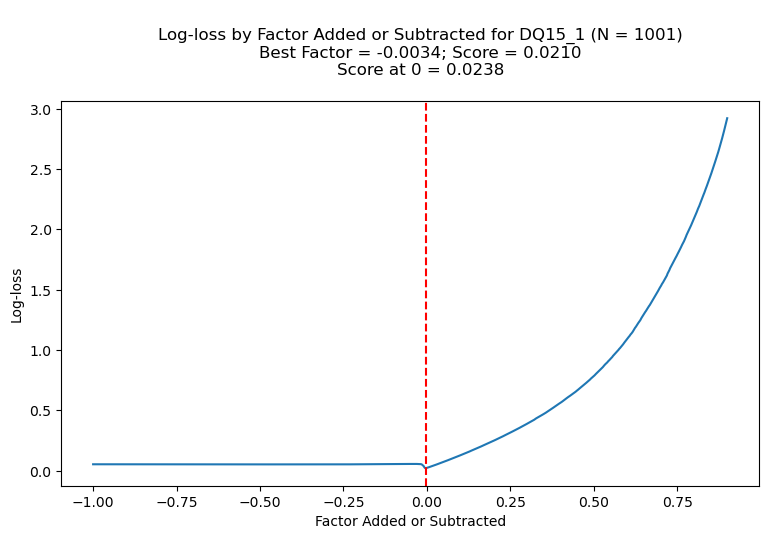

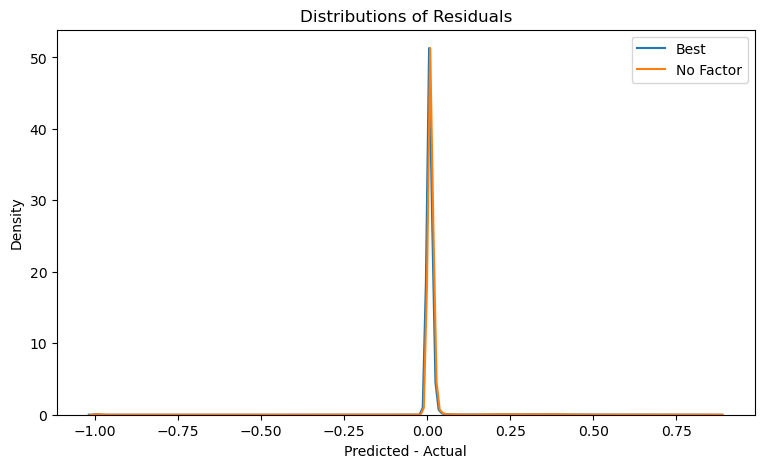

100%|██████████| 1002/1002 [00:16<00:00, 61.32it/s]


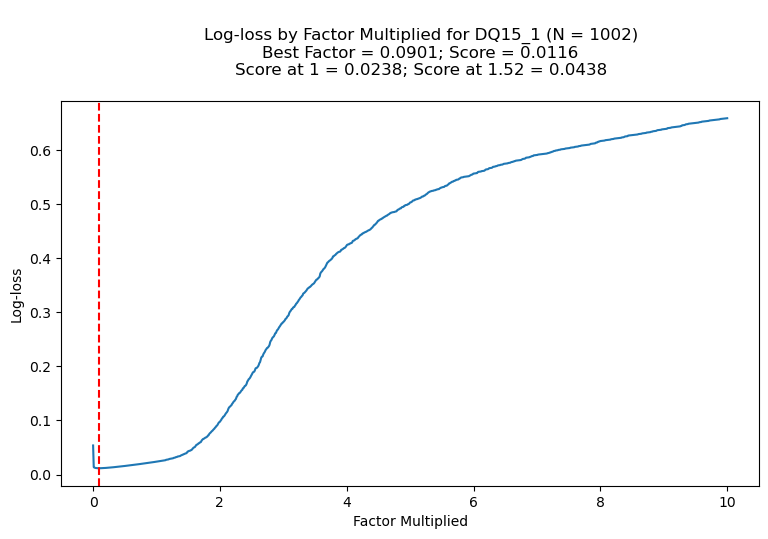

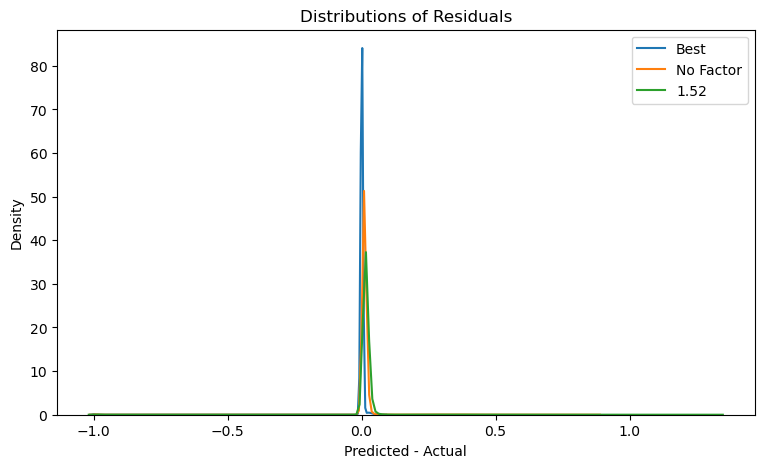

100%|██████████| 8/8 [00:01<00:00,  5.83it/s]


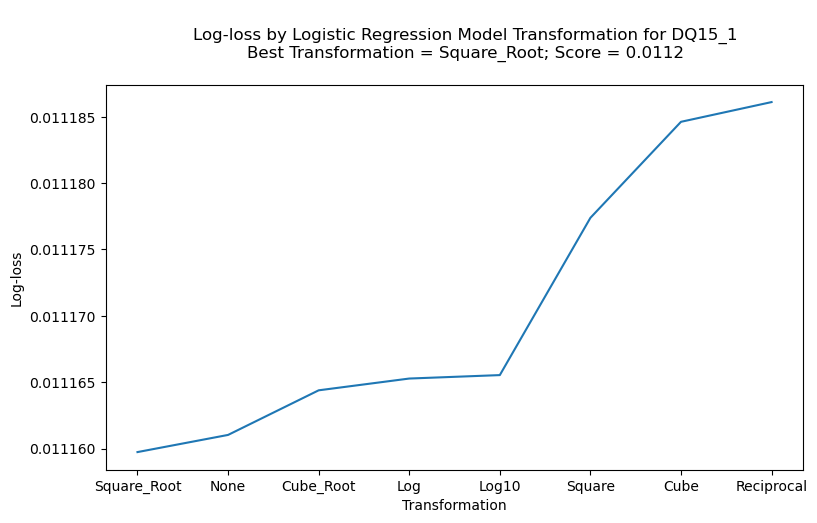

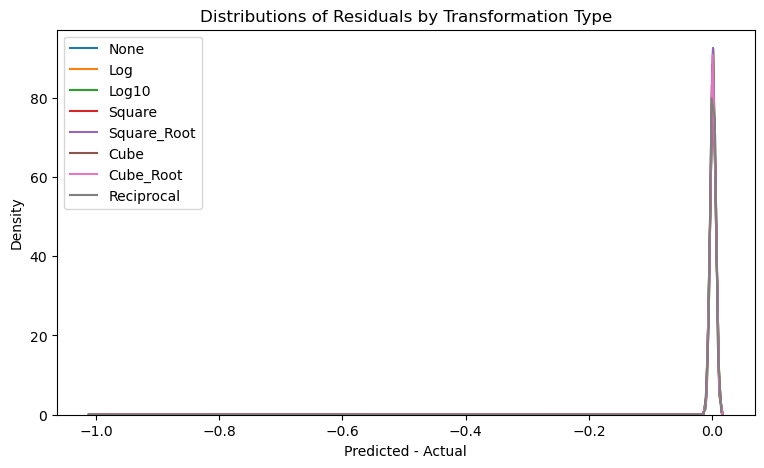



###################################################################################################################
###################################################################################################################

DQ15_2:


100%|██████████| 1001/1001 [00:16<00:00, 60.01it/s]


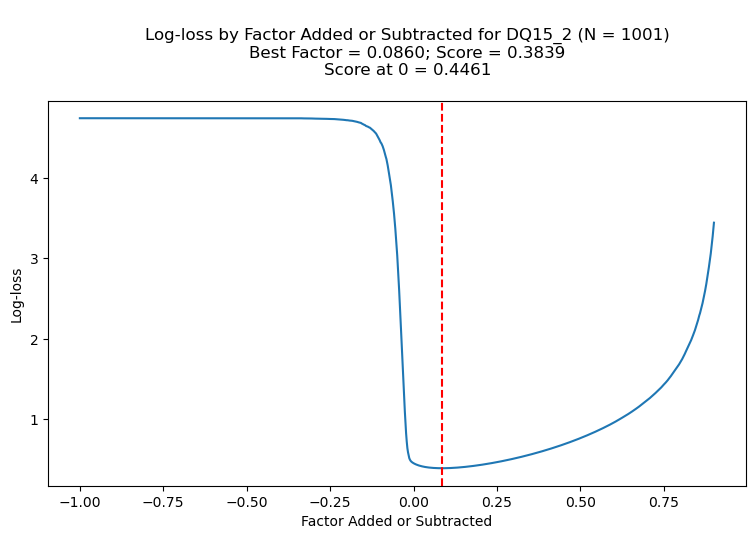

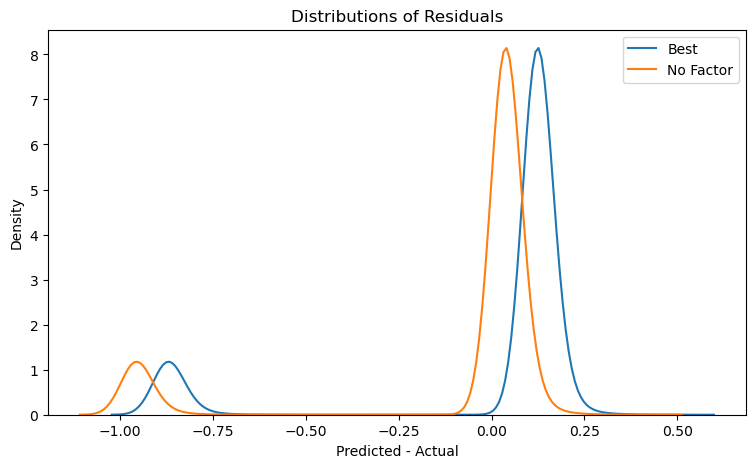

100%|██████████| 1002/1002 [00:16<00:00, 59.87it/s]


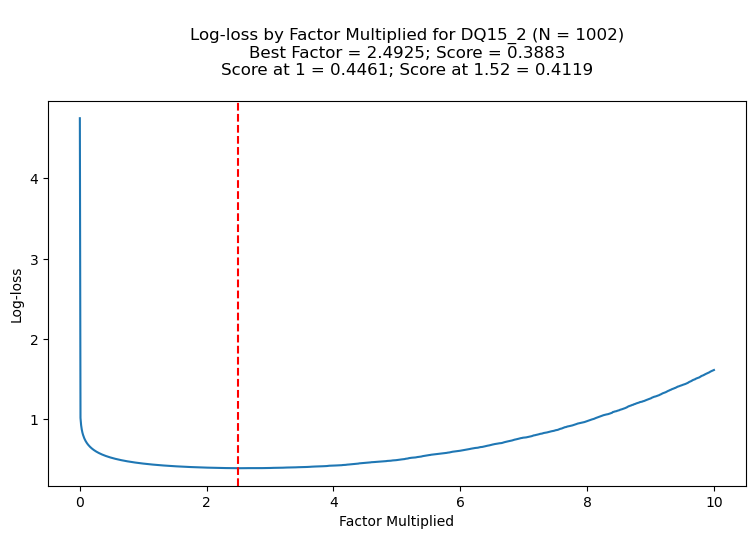

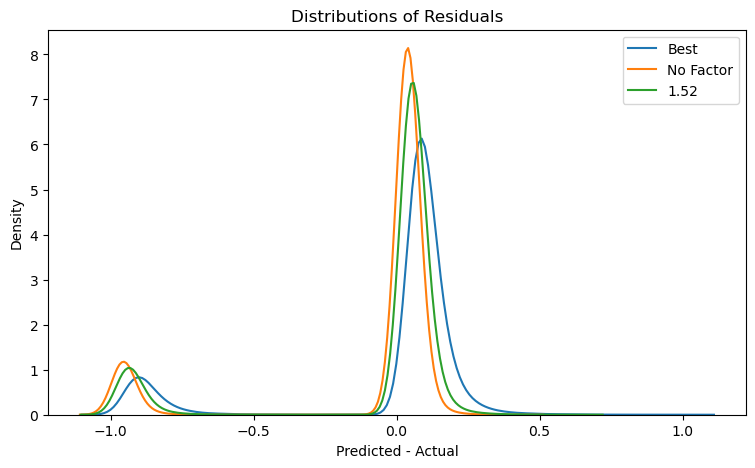

100%|██████████| 8/8 [00:01<00:00,  6.77it/s]


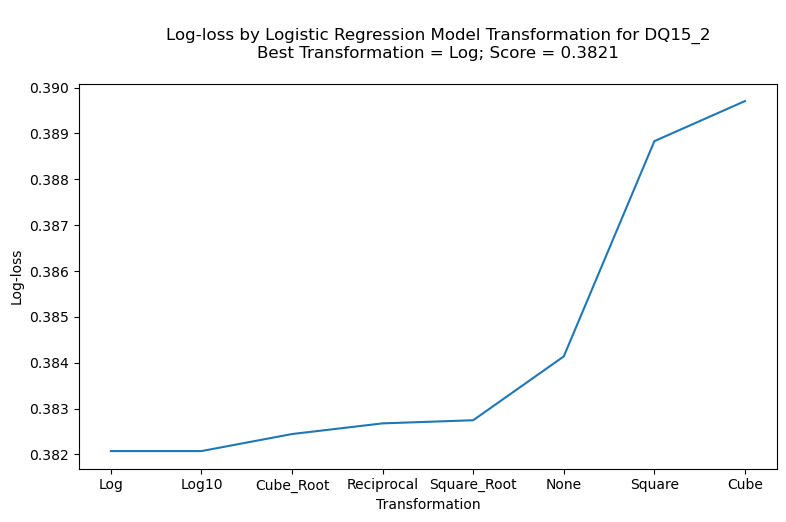

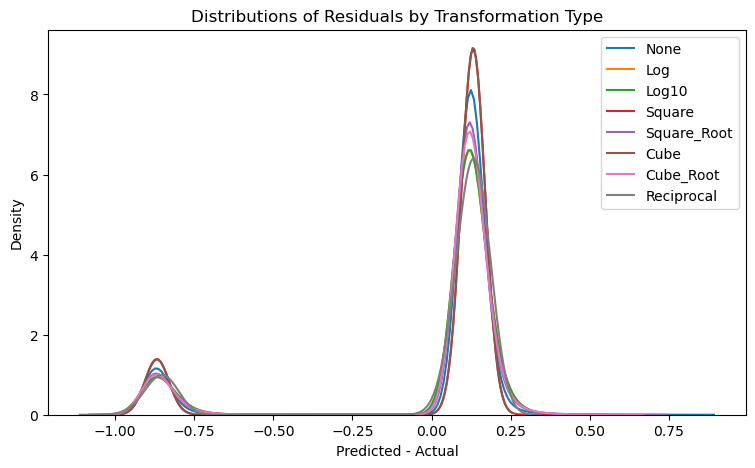



###################################################################################################################
###################################################################################################################

DQ30_2:


100%|██████████| 1001/1001 [00:16<00:00, 62.29it/s]


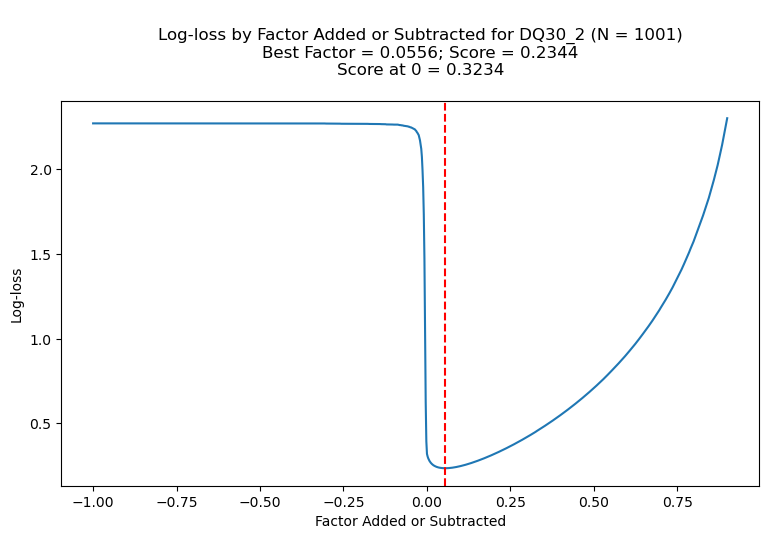

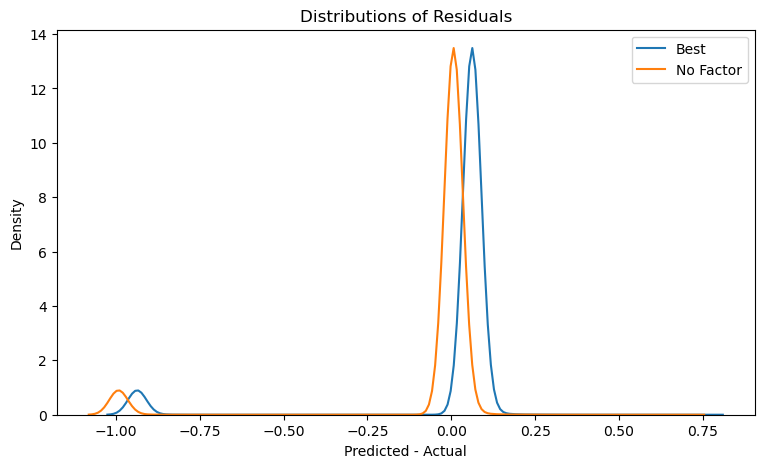

100%|██████████| 1002/1002 [00:16<00:00, 61.41it/s]


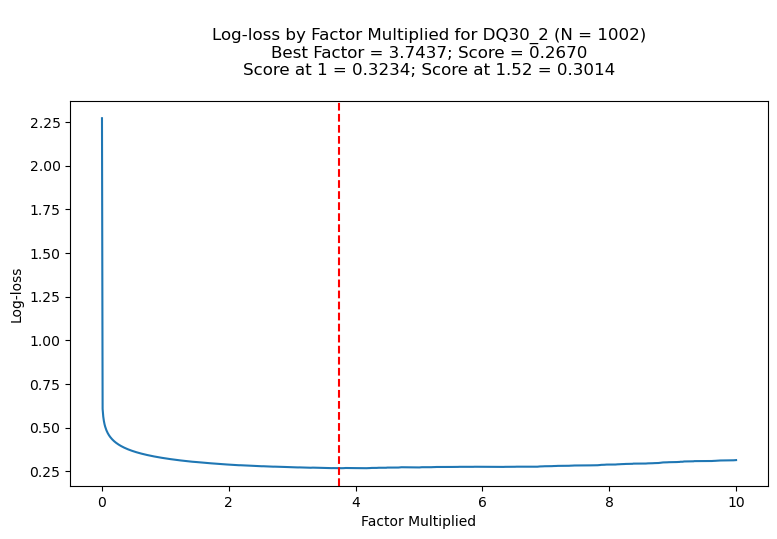

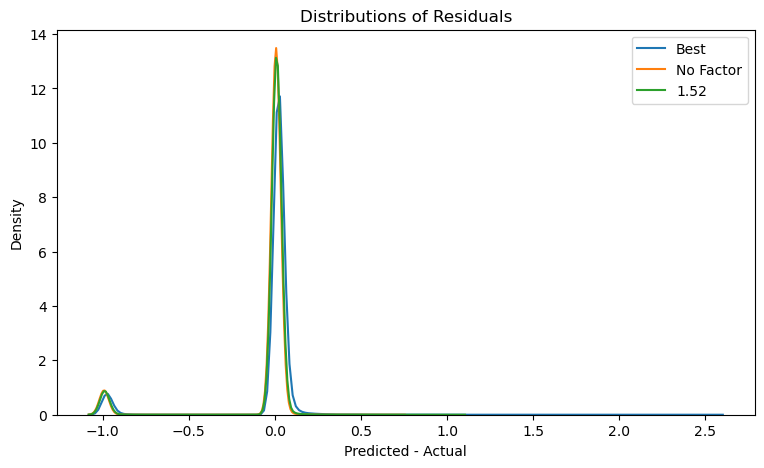

100%|██████████| 8/8 [00:01<00:00,  6.49it/s]


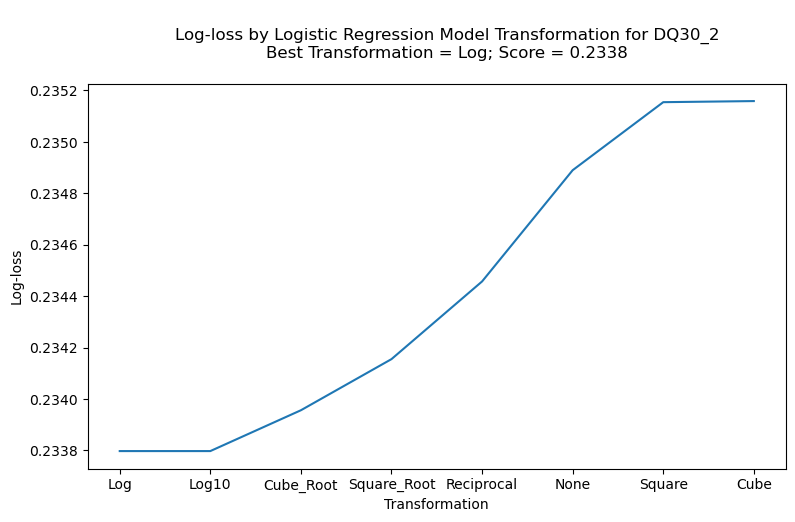

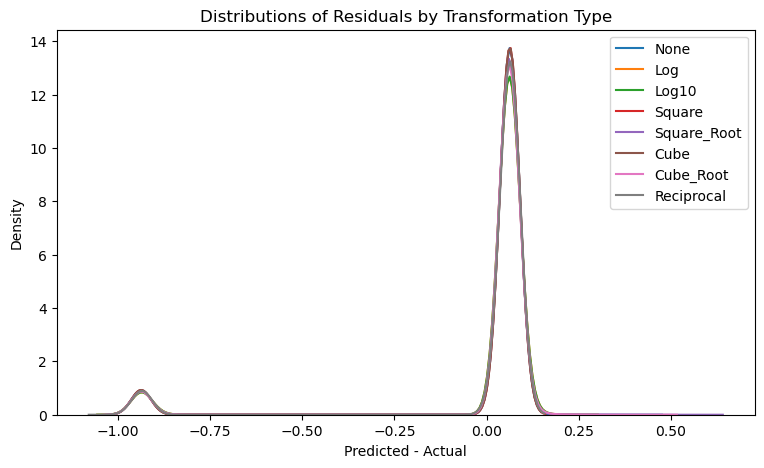



###################################################################################################################
###################################################################################################################

DQ60_3:


100%|██████████| 1001/1001 [00:15<00:00, 63.56it/s]


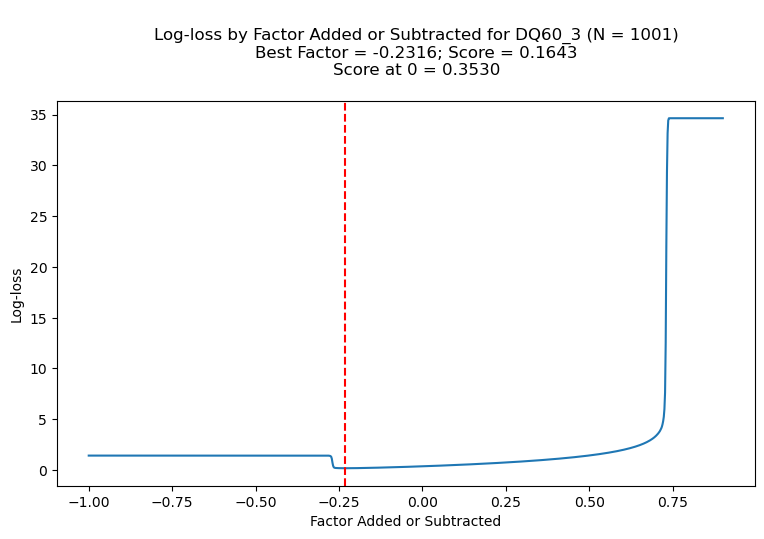

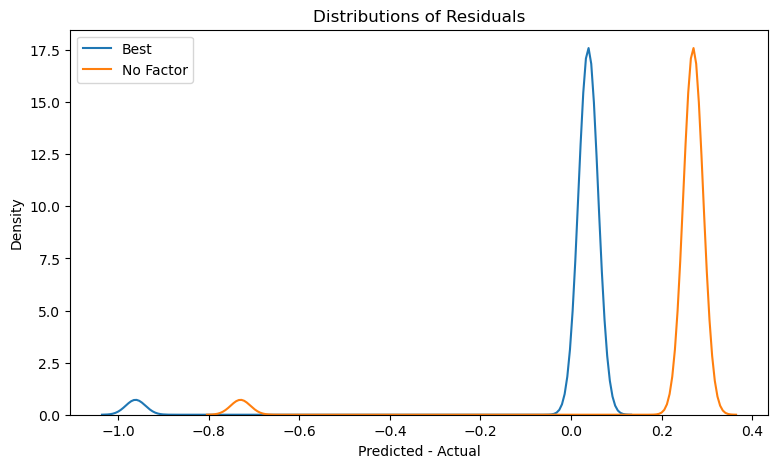

100%|██████████| 1002/1002 [00:15<00:00, 63.33it/s]


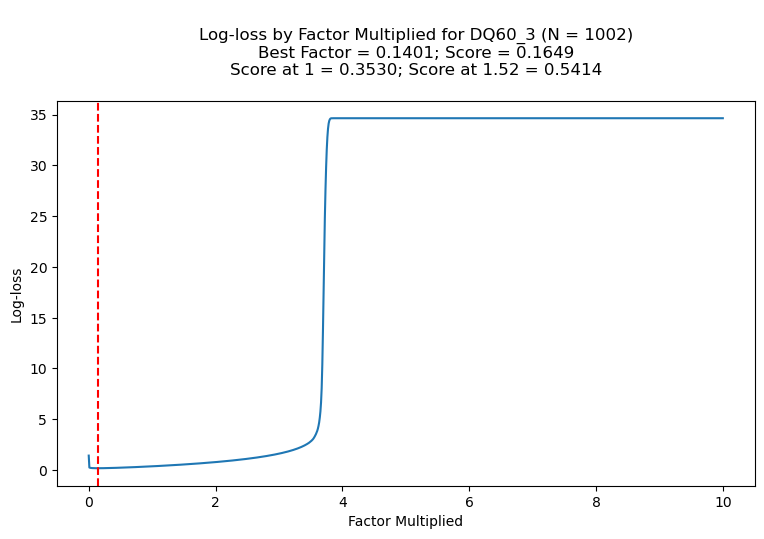

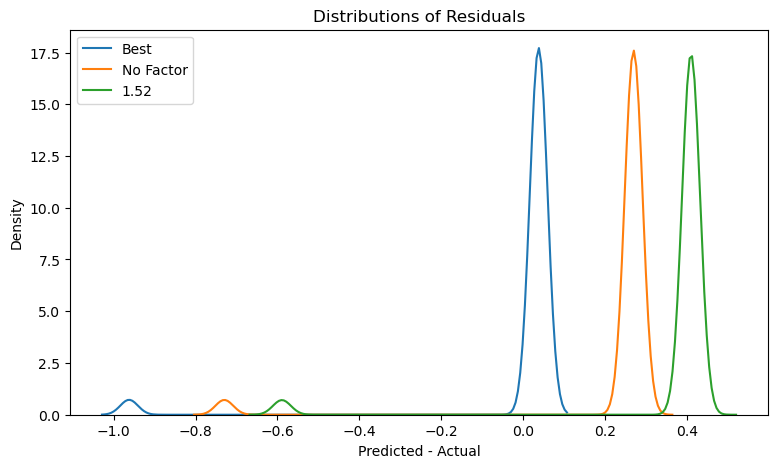

100%|██████████| 8/8 [00:01<00:00,  6.08it/s]


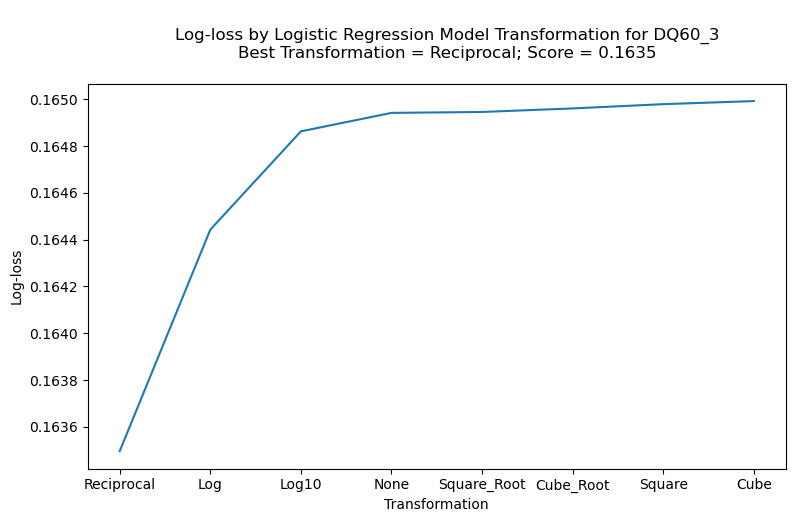

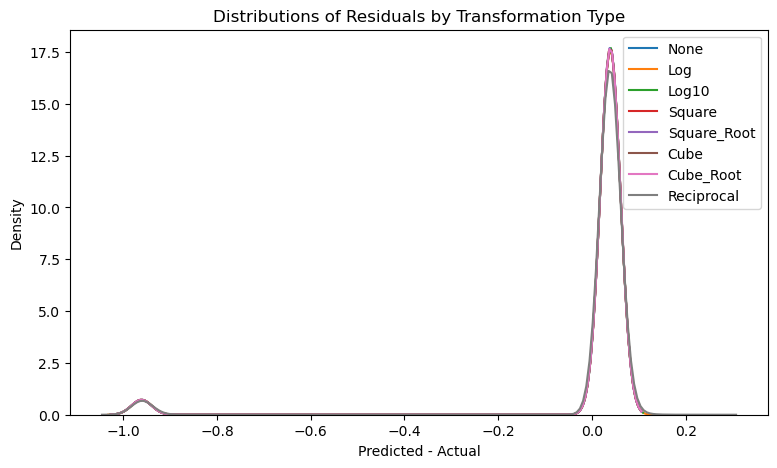



###################################################################################################################
###################################################################################################################



In [14]:
list_df = []
for key, val in dict_model_column.items():
    print(f'{key}:')
    # get predictions
    list_predictions = list(df[f'yhat_proba_{key}'])
    # get actual
    list_actual = list(df[val])
    # make df
    df_tmp = pd.DataFrame({
        'predictions': list_predictions,
        'actual': list_actual,
    })
    
    # added factors
    list_flt_factor = list(np.linspace(-1.0, 0.90, int_n_factors))
    # make sure 0 is in there
    list_flt_factor.append(0)
    # rm dups
    list_flt_factor = list(dict.fromkeys(list_flt_factor))
    # sort
    list_flt_factor.sort()
    # find
    df_added = show_best_added_factor(
        df_tmp=df_tmp, 
        list_flt_factor=list_flt_factor,
        str_key=key,
    )
    # add col
    df_added['indicator'] = key
    df_added['transformation'] = 'add_subtract'
    # append
    list_df.append(df_added)
    
    # multiplicative factors
    list_flt_factor = list(np.linspace(0, 10.0, int_n_factors))
    # make sure 1 is in there
    list_flt_factor.append(1)
    # make sure 1.52 is in there
    list_flt_factor.append(1.52)
    # rm dups
    list_flt_factor = list(dict.fromkeys(list_flt_factor))
    # sort
    list_flt_factor.sort()
    # find
    df_multiply = show_best_multiplicative_factor(
        df_tmp=df_tmp, 
        list_flt_factor=list_flt_factor,
        str_key=key,
    )
    # add col
    df_multiply['indicator'] = key
    df_multiply['transformation'] = 'multiply_divide'
    # append
    list_df.append(df_multiply)
    
    # logistic regression
    df_logistic = transformation_tuner(
        df=df, 
        str_predictor=f'yhat_proba_{key}', 
        str_target=val,
        str_key=key,
    )
    # add col
    df_logistic['indicator'] = key
    df_logistic['transformation'] = 'logistic_regression'
    # append
    list_df.append(df_logistic)
    
    # spacing
    print('')
    print('')
    print('###################################################################################################################')
    print('###################################################################################################################')
    print('')

### Get summary

In [15]:
# make df
df_out = pd.concat(list_df)
# show
df_out

,factor,score,indicator,transformation
0,-1.0,0.053714,DQ15_1,add_subtract
1,-0.998098,0.053714,DQ15_1,add_subtract
2,-0.996196,0.053714,DQ15_1,add_subtract
3,-0.994294,0.053714,DQ15_1,add_subtract
4,-0.992392,0.053714,DQ15_1,add_subtract
...,...,...,...,...
0,-3.67 + (1.74 * None(x)),0.164941,DQ60_3,logistic_regression
4,-4.07 + (1.68 * Square_Root(x)),0.164945,DQ60_3,logistic_regression
6,-4.11 + (1.40 * Cube_Root(x)),0.164960,DQ60_3,logistic_regression
3,-3.27 + (0.95 * Square(x)),0.164979,DQ60_3,logistic_regression


### Best score for each transformation for each indicator

In [16]:
list_str_transformations = list(df_out['transformation'].value_counts().index)
list_dict_row = []
for str_indicator in tqdm(dict_model_column.keys()):
    # subset
    df_tmp = df_out[df_out['indicator'] == str_indicator].copy()
    # subset again
    for str_transformation in list_str_transformations:
        # subset
        df_tmp2 = df_tmp[df_tmp['transformation'] == str_transformation].copy()
        df_tmp2.sort_values(by='score', ascending=True, inplace=True)
        # get first row
        dict_row = df_tmp2.iloc[0].to_dict()
        list_dict_row.append(dict_row)
# make df
df_summary = pd.DataFrame(list_dict_row)
# reorder
list_cols = [
    'indicator',
    'transformation',
    'factor',
    'score',
]
df_summary = df_summary[list_cols].copy()
# show
df_summary

100%|██████████| 4/4 [00:00<00:00, 267.13it/s]


,indicator,transformation,factor,score
0,DQ15_1,multiply_divide,0.09009,0.011623
1,DQ15_1,add_subtract,-0.003403,0.021016
2,DQ15_1,logistic_regression,-6.64 + (1.17 * Square_Root(x)),0.011160
3,DQ15_2,multiply_divide,2.492492,0.388301
4,DQ15_2,add_subtract,0.085986,0.383860
5,DQ15_2,logistic_regression,0.42 + (0.72 * Log(x)),0.382072
6,DQ30_2,multiply_divide,3.743744,0.267018
7,DQ30_2,add_subtract,0.055556,0.234413
8,DQ30_2,logistic_regression,-1.14 + (0.31 * Log(x)),0.233798
9,DQ60_3,multiply_divide,0.14014,0.164901


### Best score for each indicator

In [17]:
list_dict_row = []
for str_indicator in tqdm(dict_model_column.keys()):
    # subset
    df_tmp = df_out[df_out['indicator'] == str_indicator].copy()
    # sort
    df_tmp.sort_values(by='score', ascending=True, inplace=True)
    # get first row
    dict_row = df_tmp.iloc[0].to_dict()
    # append
    list_dict_row.append(dict_row)
# df
df_summary = pd.DataFrame(list_dict_row)
# reorder
list_cols = [
    'indicator',
    'transformation',
    'factor',
    'score',
]
df_summary = df_summary[list_cols].copy()
# show
df_summary

100%|██████████| 4/4 [00:00<00:00, 598.40it/s]


,indicator,transformation,factor,score
0,DQ15_1,logistic_regression,-6.64 + (1.17 * Square_Root(x)),0.011160
1,DQ15_2,logistic_regression,0.42 + (0.72 * Log(x)),0.382072
2,DQ30_2,logistic_regression,-1.14 + (0.31 * Log(x)),0.233798
3,DQ60_3,logistic_regression,17.82 + (-5.67 * Reciprocal(x)),0.163496
